# Machine-Learning Programm

##  (Train & Test = gleiche Daten)

## Importing gcode in csv-file

In [1]:
#import data from csv file for further processing
import pandas as pd
import numpy as np

df_filepath = './df_parsed.csv'
df = pd.read_csv(df_filepath, index_col=['Unnamed: 0'])


#pd.set_option("display.max_rows", None, "display.max_columns", None)
df.describe()
#df.head()
#df.tail()
#df.columns

,X,Y,Z,I,J,delta_xy,delta_X,delta_Y,delta_Z,delta_S,F_val,D_W,S,TurnOp,Toolchange,ENERGY|x,ENERGY|y,ENERGY|z,ENERGY|S,ENERGY|T
count,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2.213000e+03,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000
mean,-1.300142,1.552118,285.452850,-0.008438,0.016631,2.128933,0.553685,1.810044,2.054891e-16,0.000000,120.208766,4.382738,4584.274740,0.001808,0.004067,4.129043,1.478090,2.903118,118.339919,1.492249
std,6.403329,21.329063,303.116148,2.433507,0.865189,8.751811,1.789431,8.622186,5.131558e+01,694.202289,264.405105,3.416697,5465.059687,0.042486,0.063657,46.044159,8.667296,52.573514,857.416625,13.030186
min,-19.907000,-70.500000,-8.000000,-14.300000,-7.300000,0.000000,0.000000,0.000000,-6.070000e+02,-13000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-129.385580,-8043.649349,0.000000
25%,-0.100000,-2.262000,-3.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,2.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.262000,610.000000,0.000000,0.000000,0.632001,0.000000,0.085000,0.000000e+00,0.000000,0.000000,8.000000,10000.000000,0.000000,0.000000,0.000000,0.083114,0.000000,101.593985,0.000000
max,14.300000,67.500000,610.000000,14.300000,7.300000,134.100000,25.906000,134.100000,6.070000e+02,13000.000000,750.000000,10.000000,13000.000000,1.000000,1.000000,570.195688,134.946734,940.387548,14158.866014,281.044521


## One-Hot categorical encoding

In [2]:
dfCompare = df.copy()
df = pd.get_dummies(df, columns=["Commands", 'D'])
list(df.columns.values)

['N',
 'G',
 'M',
 'X',
 'Y',
 'Z',
 'I',
 'J',
 'F',
 'delta_xy',
 'delta_X',
 'delta_Y',
 'delta_Z',
 'delta_S',
 'F_val',
 'D_W',
 'Werkzeug',
 'Bearbeitung',
 'S',
 'T=',
 'TurnOp',
 'Toolchange',
 'TURN',
 'GCode',
 'ENERGY|x',
 'ENERGY|y',
 'ENERGY|z',
 'ENERGY|S',
 'ENERGY|T',
 'Commands_G0',
 'Commands_G0 G40 G60',
 'Commands_G0 M106',
 'Commands_G0 M3',
 'Commands_G09',
 'Commands_G1',
 'Commands_G1 G60',
 'Commands_G2',
 'Commands_G4',
 'Commands_G40',
 'Commands_G41',
 'Commands_G41 G1',
 'Commands_G4F1',
 'Commands_G54 G0',
 'Commands_G90',
 'Commands_G91',
 'Commands_G94',
 'Commands_G94 G1 G90',
 'Commands_G94 G3 G90',
 'Commands_M168',
 'Commands_M169 M167',
 'Commands_M17',
 'Commands_M27 M28',
 'Commands_M5',
 'Commands_M58,',
 'Commands_M59',
 'Commands_MSG',
 'D_D0',
 'D_D1',
 'D_D=$P_TOOL']

## Visualize Data and show dependencies

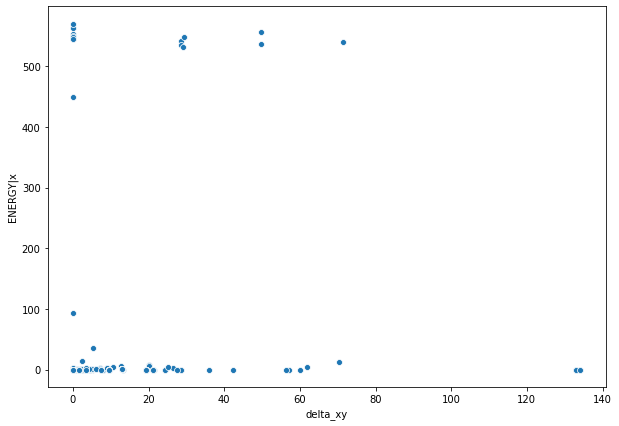

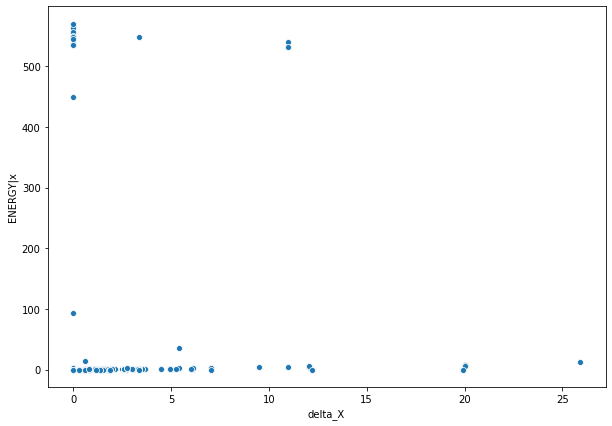

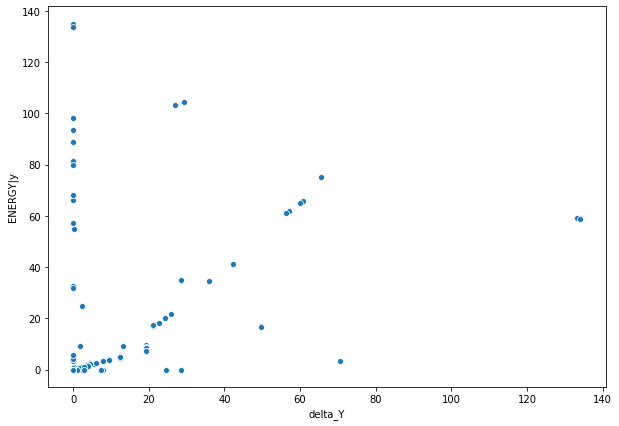

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Examine the data by sight

#df.plot(figsize=(30,10))

plt.figure(figsize = (10, 7))
sns.scatterplot(x = df['delta_xy'], 
                y = df['ENERGY|x'])

plt.figure(figsize = (10, 7))
sns.scatterplot(x = df['delta_X'], 
                y = df['ENERGY|x'])
                #hue = df['Commands'])
                #palette=['dodgerblue','orange', 'green','red'],)
        
plt.figure(figsize = (10, 7))
sns.scatterplot(x = df['delta_Y'],
                y = df['ENERGY|y'])
                #hue = df['Commands'])
                #palette=['dodgerblue','orange', 'green','red'],)

## Split dataset and train model

In [4]:
#split dataset into train and test dataset

from sklearn.model_selection import train_test_split

#df_cleaned = df.iloc[1:,]
toPredict = ['ENERGY|x', 'ENERGY|y', 'ENERGY|z', 'ENERGY|S', 'ENERGY|T']
y = df[toPredict]
features = ['delta_X', 'delta_Y', 'delta_Z', 'delta_S', 'F_val', 'S', 'D_W', 'Toolchange', 'TurnOp',
 'Commands_G0',
 'Commands_G0 G40 G60',
 'Commands_G0 M106',
 'Commands_G0 M3',
 'Commands_G09',
 'Commands_G1',
 'Commands_G1 G60',
 'Commands_G2',
 'Commands_G4',
 'Commands_G40',
 'Commands_G41',
 'Commands_G41 G1',
 'Commands_G4F1',
 'Commands_G54 G0',
 'Commands_G90',
 'Commands_G91',
 'Commands_G94',
 'Commands_G94 G1 G90',
 'Commands_G94 G3 G90',
 'Commands_M168',
 'Commands_M169 M167',
 'Commands_M17',
 'Commands_M27 M28',
 'Commands_M5',
 'Commands_M58,',
 'Commands_M59',
 'Commands_MSG',
 'D_D0',
 'D_D1',
 'D_D=$P_TOOL']
X = df[features]
#X = df_cleaned[df_features]

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.15, random_state = 1)

In [5]:
#build ML-model an train it

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.multioutput import MultiOutputRegressor


test_model = RandomForestRegressor(random_state = 1)
#test_model = MultiOutputRegressor(AdaBoostRegressor(DecisionTreeRegressor( )))#n_estimators = 5000,
#                                                                          max_depth=5, 
#                                                                          random_state=1, 
#                                                                          min_samples_leaf=1, 
#                                                                          min_samples_split = 2)))

#MODEL TRAINING

#test_model.fit(train_X, train_y)
test_model.fit(X, y)

#PREDICTIONS

predictions = test_model.predict(X)
#predictions = test_model.predict(test_X)

df_pred = pd.DataFrame(data=predictions) #.flatten()
df_pred
#df_test = test_y.set_index(df_pred.index) 
#df_test

,0,1,2,3,4
0,2.813236,0.467707,101.740464,-329.080923,1.423255
1,2.813236,0.467707,101.740464,-329.080923,1.423255
2,0.000000,0.000000,6.714769,4.305998,0.000000
3,0.000000,0.000000,6.714769,4.305998,0.000000
4,0.000000,0.014813,-0.002333,0.000000,0.092763
...,...,...,...,...,...
2208,8.638172,1.360249,0.000000,-685.828604,0.503554
2209,27.084200,1.629831,0.000000,-1735.975893,1.781366
2210,0.000000,0.000000,0.000000,-1.212235,0.188384
2211,0.000000,0.000000,0.000000,-1.212235,0.188384


##  Vergleich der Vorhersagen

### Überblick

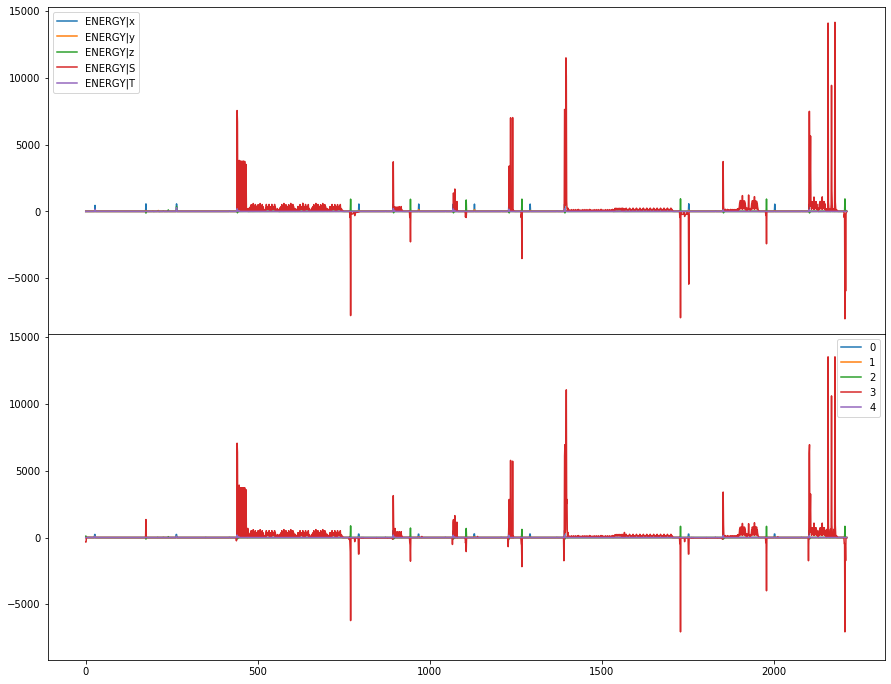

In [6]:
from sklearn.metrics import mean_absolute_error
from math import sqrt, pow

fig, axs = plt.subplots(2, sharex=True, sharey=True, gridspec_kw={'hspace': 0}, figsize=(15,12))

#y = df_pred
y.plot(ax=axs[0]) 
df_pred.plot(ax=axs[1])

### X-Achse

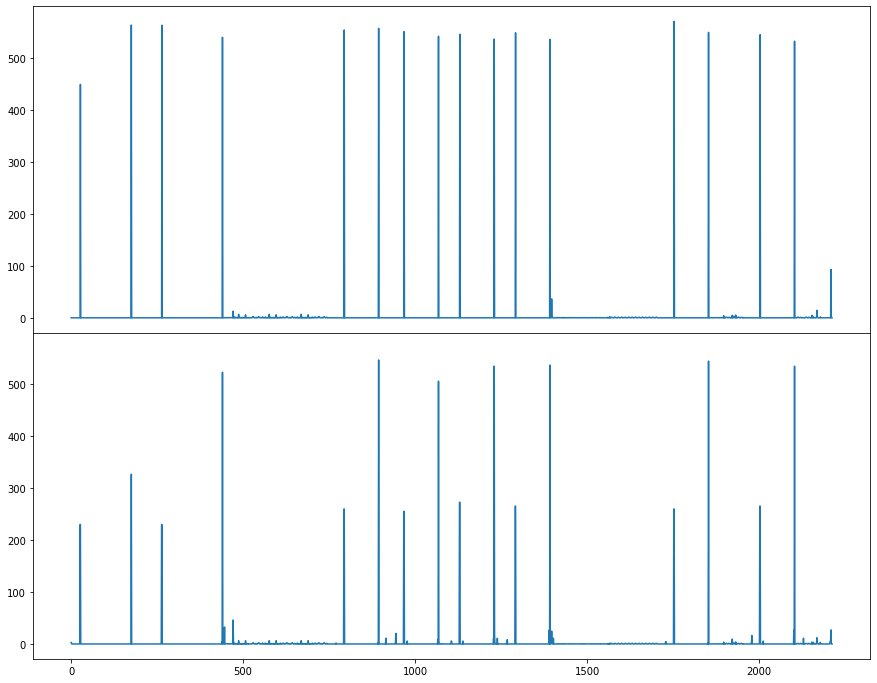

In [7]:
fig, axs = plt.subplots(2, sharex=True, sharey=True, gridspec_kw={'hspace': 0}, figsize=(15,12))

y['ENERGY|x'].plot(ax=axs[0]) 
df_pred[0].plot(ax=axs[1])

### y - Achse

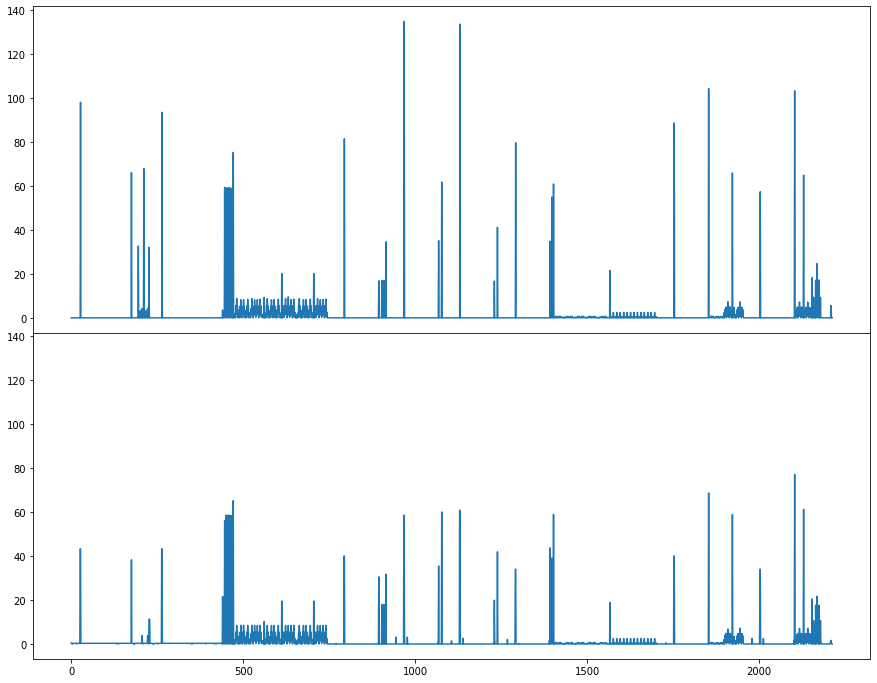

In [8]:
fig, axs = plt.subplots(2, sharex=True, sharey=True, gridspec_kw={'hspace': 0}, figsize=(15,12))

y['ENERGY|y'].plot(ax=axs[0]) 
df_pred[1].plot(ax=axs[1])

### z Achse

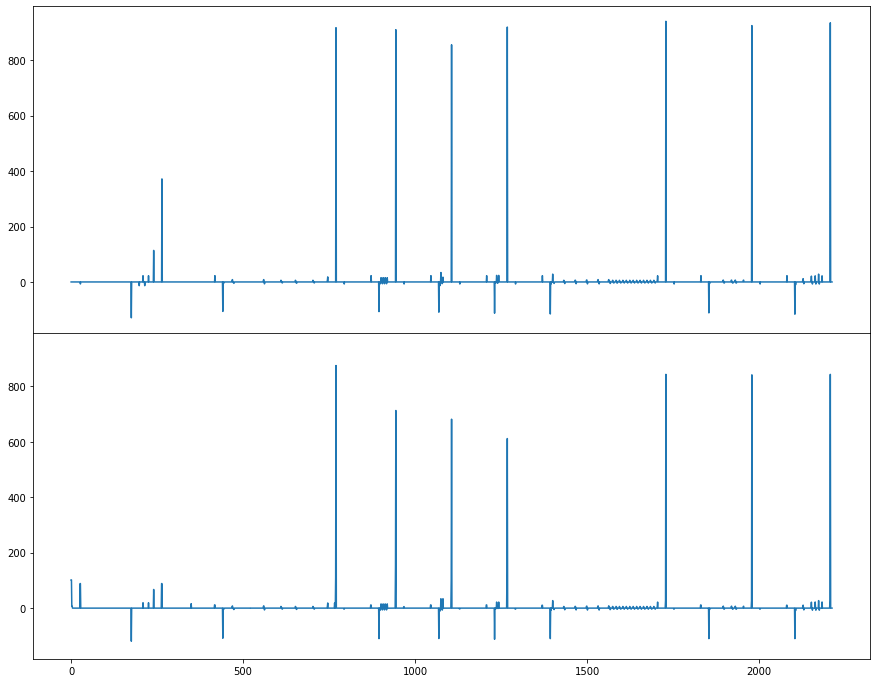

In [9]:
fig, axs = plt.subplots(2, sharex=True, sharey=True, gridspec_kw={'hspace': 0}, figsize=(15,12))

y['ENERGY|z'].plot(ax=axs[0]) 
df_pred[2].plot(ax=axs[1])

### Spindel

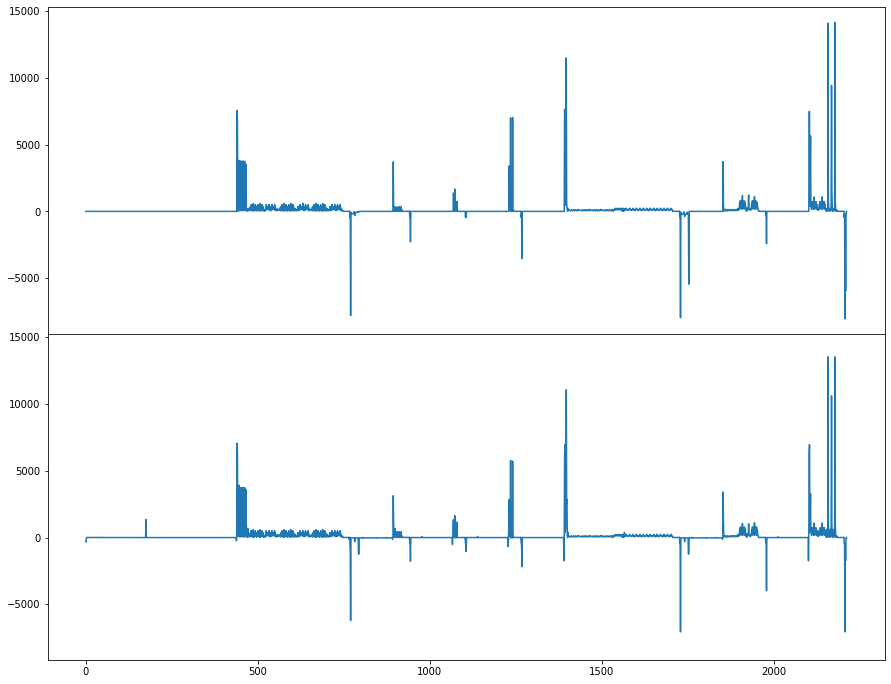

In [10]:
fig, axs = plt.subplots(2, sharex=True, sharey=True, gridspec_kw={'hspace': 0}, figsize=(15,12))

y['ENERGY|S'].plot(ax=axs[0]) 
df_pred[3].plot(ax=axs[1])

### Toolchange

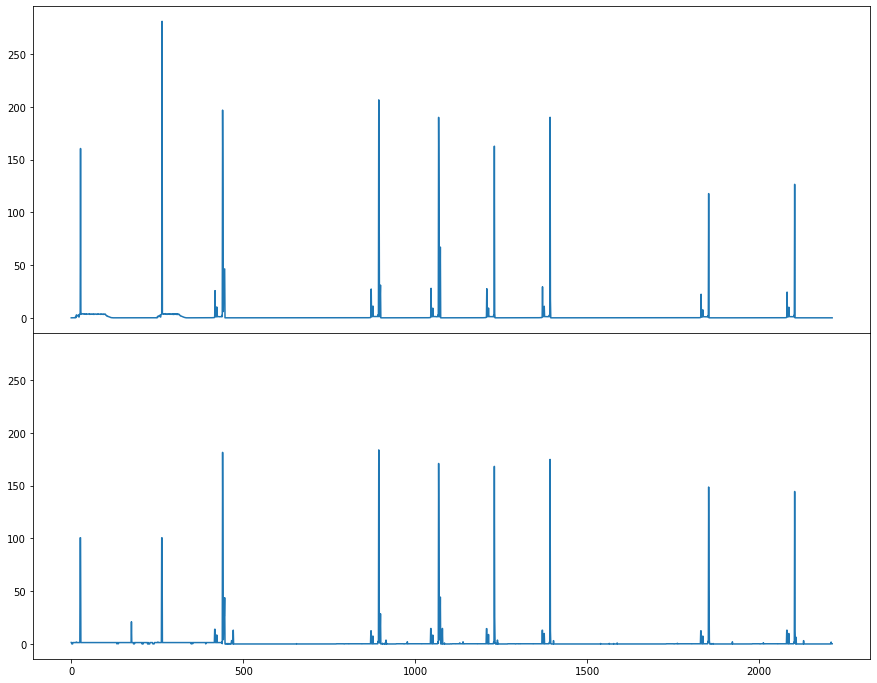

In [11]:
fig, axs = plt.subplots(2, sharex=True, sharey=True, gridspec_kw={'hspace': 0}, figsize=(15,12))

y['ENERGY|T'].plot(ax=axs[0]) 
df_pred[4].plot(ax=axs[1])

## Vorhersagegüte Quantifizieren

In [12]:
from sklearn.metrics import mean_absolute_error
from math import sqrt, pow
from sklearn.metrics import mean_squared_error
from sklearn.metrics import explained_variance_score
from sklearn.metrics import r2_score
from math import sqrt

#activate for Train-Test-Split 
#y_true = df_test
#y = y_true

#activate for complete dataset
y_true = y
y_pred = df_pred

gesAbwArr = []
maeArr = []
rmsArr = []
exVarArr = []

scoresFrame = pd.DataFrame()

for j in range(len(y.columns)):
    deviation = []
    for i in range(len(y.index)):
        if y.iloc[i, j] == 0 and df_pred.iloc[i, j] == 0:
            deviation.append(0)
        elif y.iloc[i, j] == 0:
            deviation.append(0)
        else:    
            deviation.append( ( y.iloc[i, j] - df_pred.iloc[i, j]) / y.iloc[i, j])
    scoresFrame.insert(j, str(j), deviation)
    #scoresFrame[str(j)] = deviation

    mae = round(mean_absolute_error(y.iloc[:,j], df_pred.iloc[:,j]), 2)
    
    exVar = round(explained_variance_score(y.iloc[:,j], df_pred.iloc[:,j]), 2)
    r2 = round(r2_score(y.iloc[:,j], df_pred.iloc[:,j]), 2)
    
    
    rms = round(sqrt(mean_squared_error(y_true.iloc[:,j], y_pred.iloc[:,j])), 2)
    
    sum_deviation = 0
    for i in range(len(scoresFrame)):
        sum_deviation += abs(scoresFrame.iloc[i, j])  #Fehler?
    mean_deviation = sum_deviation / len(scoresFrame)
    mre = round(mean_deviation * 100, 2)
    mre2 = round(mae/(y.iloc[:,j].mean())*100, 2)
    gesAbw = round((((y.iloc[:, j].sum() / df_pred.iloc[:, j].sum())-1)*100), 2)
    
    gesAbwArr.append(gesAbw)
    maeArr.append(mae)
    rmsArr.append(rms)
    exVarArr.append(exVar)
    
    print(f'\n------------------------------------ \n' 
          f'{y.columns[j]}\n' 
          f'Gesammtabweichung {gesAbw}%\n' 
          f'mean absolut error: {mae} Ws. \n' 
          f'RMSE: {rms}\n'
          f'Explained Variance: {exVar}\n'
          f'------------------------------------\n')
    
#          f'R2: {r2}\n'    
#          f'mean of deviations: \u00B1 {mre}% \n' 
#          f'mae/mean_meassured: \u00B1 {mre2}%\n' 

print(gesAbwArr)
print(maeArr)
print(rmsArr)
print(exVarArr)
print()

row = 10    
print(y.iloc[[row]])
print(df_pred.iloc[[row]])
print(scoresFrame.iloc[[row]])


------------------------------------ 
ENERGY|x
Gesammtabweichung 3.33%
mean absolut error: 2.3 Ws. 
RMSE: 23.76
Explained Variance: 0.73
------------------------------------


------------------------------------ 
ENERGY|y
Gesammtabweichung 3.6%
mean absolut error: 0.59 Ws. 
RMSE: 4.75
Explained Variance: 0.7
------------------------------------


------------------------------------ 
ENERGY|z
Gesammtabweichung 2.89%
mean absolut error: 1.27 Ws. 
RMSE: 13.23
Explained Variance: 0.94
------------------------------------


------------------------------------ 
ENERGY|S
Gesammtabweichung 1.58%
mean absolut error: 36.96 Ws. 
RMSE: 231.08
Explained Variance: 0.93
------------------------------------


------------------------------------ 
ENERGY|T
Gesammtabweichung 3.52%
mean absolut error: 0.89 Ws. 
RMSE: 5.81
Explained Variance: 0.8
------------------------------------

[3.33, 3.6, 2.89, 1.58, 3.52]
[2.3, 0.59, 1.27, 36.96, 0.89]
[23.76, 4.75, 13.23, 231.08, 5.81]
[0.73, 0.7, 0.94, 0.93,

## Feature Importance

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.ensemble import ExtraTreesClassifier

# # Build a classification task using 3 informative features
# X, y = make_classification(n_samples=1000,
#                            n_features=10,
#                            n_informative=3,
#                            n_redundant=0,
#                            n_repeated=0,
#                            n_classes=2,
#                            random_state=0,
#                            shuffle=False)

# # Build a forest and compute the impurity-based feature importances
# forest = ExtraTreesClassifier(n_estimators=250,
#                               random_state=0)

# forest.fit(X, y)

importances = test_model.feature_importances_
std = np.std([tree.feature_importances_ for tree in test_model.estimators_],
             axis=0)
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")

for f in range(X.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

Feature ranking:
1. feature 8 (0.358939)
2. feature 2 (0.119085)
3. feature 3 (0.098041)
4. feature 1 (0.094621)
5. feature 5 (0.069303)
6. feature 6 (0.058254)
7. feature 27 (0.043544)
8. feature 36 (0.034922)
9. feature 17 (0.032524)
10. feature 15 (0.029309)
11. feature 0 (0.027932)
12. feature 4 (0.012087)
13. feature 12 (0.005758)
14. feature 9 (0.004064)
15. feature 23 (0.003268)
16. feature 26 (0.003158)
17. feature 35 (0.001720)
18. feature 14 (0.001414)
19. feature 16 (0.000642)
20. feature 37 (0.000571)
21. feature 32 (0.000508)
22. feature 31 (0.000131)
23. feature 28 (0.000105)
24. feature 22 (0.000059)
25. feature 11 (0.000017)
26. feature 29 (0.000008)
27. feature 18 (0.000007)
28. feature 10 (0.000003)
29. feature 38 (0.000002)
30. feature 25 (0.000002)
31. feature 19 (0.000002)
32. feature 7 (0.000001)
33. feature 24 (0.000001)
34. feature 20 (0.000000)
35. feature 13 (0.000000)
36. feature 30 (0.000000)
37. feature 33 (0.000000)
38. feature 34 (0.000000)
39. feature 21

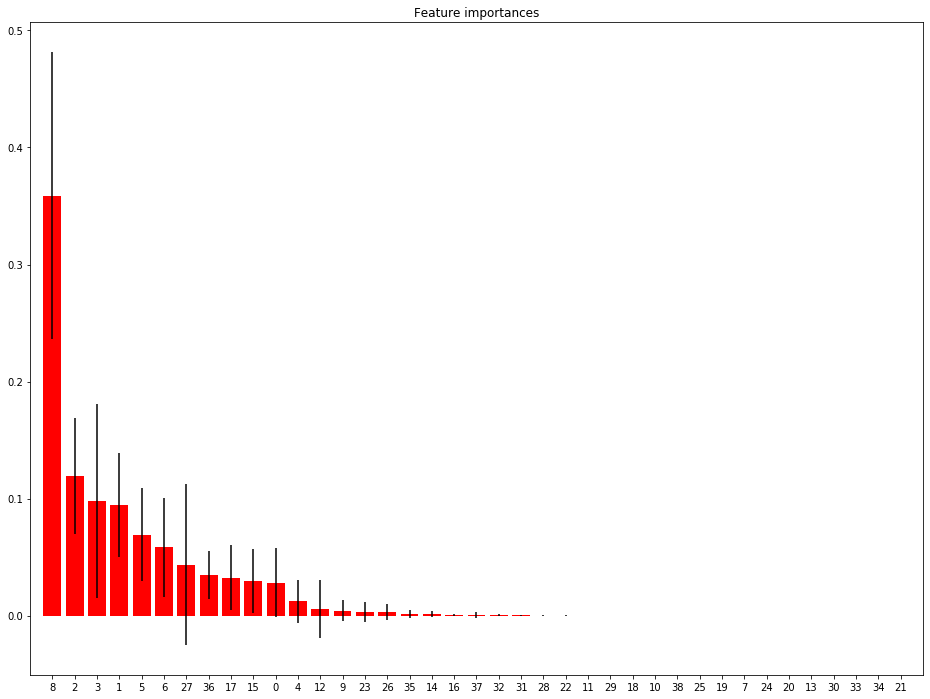

In [14]:
# Plot the impurity-based feature importances of the forest
plt.figure(figsize = (16,12))
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices],
        color="r", yerr=std[indices], align="center")
plt.xticks(range(X.shape[1]), indices)
plt.xlim([-1, X.shape[1]])
plt.show()

## Show datapoints with highest errors

In [15]:
absErrors = pd.DataFrame()

for j in range(len(y.columns)):
    deviation = []
    for i in range(len(y.index)):
        deviation.append(abs(y.iloc[i, j] - df_pred.iloc[i, j]))
    absErrors.insert(j, str(j), deviation)

#absErrors
dfErrors = pd.concat([dfCompare, absErrors], axis = 1)
dfErrors

,N,Commands,G,M,X,Y,Z,I,J,F,...,ENERGY|x,ENERGY|y,ENERGY|z,ENERGY|S,ENERGY|T,0,1,2,3,4
0,N32,G0,G0,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,0.000000,0.0,2.813236,0.467707,101.740464,329.080923,1.423255
1,N32,G0,G0,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,0.000000,0.0,2.813236,0.467707,101.740464,329.080923,1.423255
2,N34,G0,G0,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,6.714769,4.305998,0.000000
3,N34,G0,G0,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,6.714769,4.305998,0.000000
4,NaN,MSG,,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.014813,0.002333,0.000000,0.092763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2208,N1842,G4,G4,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,-219.734254,0.0,8.638172,1.360249,0.000000,466.094350,0.503554
2209,N1842,G4,G4,,0.0,0.0,610.0,0.0,0.0,NaN,...,93.042402,5.59896,0.0,-5963.601137,0.0,65.958202,3.969130,0.000000,4227.625244,1.781366
2210,N1844,MSG,,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,-219.693970,0.0,0.000000,0.000000,0.000000,218.481735,0.188384
2211,N1844,MSG,,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,-59.709629,0.0,0.000000,0.000000,0.000000,58.497393,0.188384


In [16]:
dfErrors

,N,Commands,G,M,X,Y,Z,I,J,F,...,ENERGY|x,ENERGY|y,ENERGY|z,ENERGY|S,ENERGY|T,0,1,2,3,4
0,N32,G0,G0,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,0.000000,0.0,2.813236,0.467707,101.740464,329.080923,1.423255
1,N32,G0,G0,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,0.000000,0.0,2.813236,0.467707,101.740464,329.080923,1.423255
2,N34,G0,G0,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,6.714769,4.305998,0.000000
3,N34,G0,G0,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,6.714769,4.305998,0.000000
4,NaN,MSG,,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.014813,0.002333,0.000000,0.092763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2208,N1842,G4,G4,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,-219.734254,0.0,8.638172,1.360249,0.000000,466.094350,0.503554
2209,N1842,G4,G4,,0.0,0.0,610.0,0.0,0.0,NaN,...,93.042402,5.59896,0.0,-5963.601137,0.0,65.958202,3.969130,0.000000,4227.625244,1.781366
2210,N1844,MSG,,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,-219.693970,0.0,0.000000,0.000000,0.000000,218.481735,0.188384
2211,N1844,MSG,,,0.0,0.0,610.0,0.0,0.0,NaN,...,0.000000,0.00000,0.0,-59.709629,0.0,0.000000,0.000000,0.000000,58.497393,0.188384
